In [279]:
#importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as mp
from sklearn.cluster import KMeans
import seaborn as sb
import os 

In [281]:
os.chdir("C:/Users/Adriana Rangel/Downloads")

In [283]:
#subir archivos
sales=pd.read_csv("FACT_SALES.csv")
calendar=pd.read_excel("DIM_CALENDAR.xlsx")
product=pd.read_excel("DIM_PRODUCT.xlsx")
segment=pd.read_excel("DIM_SEGMENT.xlsx")



In [284]:
#renombrar columnas
sales.rename(columns = {"WEEK":"SEMANA DEL AÑO","ITEM_CODE":"CODIGO","TOTAL_UNIT_SALES":"TOTAL DE UNIDADES VENDIDAS","TOTAL_VALUE_SALES":"VALOR TOTAL DE VENTAS","TOTAL_UNIT_AVG_WEEKLY_SALES":"TOTAL DE UNIDADES PROMEDIO SEMANAL"}, inplace=True)
sales.head()

,SEMANA DEL AÑO,CODIGO,TOTAL DE UNIDADES VENDIDAS,VALOR TOTAL DE VENTAS,TOTAL DE UNIDADES PROMEDIO SEMANAL,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5


In [286]:
#renombrar columnas
calendar.rename(columns={"WEEK":"SEMANA DEL AÑO","YEAR":"AÑO","MONTH":"MES","WEEK_NUMBER":"NUMERO DE SEMANAS","DATE":"FECHA"}, inplace=True)
calendar.head()

,SEMANA DEL AÑO,AÑO,MES,NUMERO DE SEMANAS,FECHA
0,01-21,2021,1,1,2021-01-10
1,02-21,2021,1,2,2021-01-17
2,03-21,2021,1,3,2021-01-24
3,04-21,2021,1,4,2021-01-31
4,05-21,2021,2,5,2021-02-07


In [289]:
#renombrar columnas
product.rename(columns={"MANUFACTURER":"FABRICANTE","BRAND":"MARCA","ITEM":"CODIGO","ITEM_DESCRIPTION":"DESCRIPCIÓN DEL PRODUCTO","CATEGORY":"CATEGORIA","FORMAT":"FORMATO"},inplace=True)
product.head()

,FABRICANTE,MARCA,CODIGO,DESCRIPCIÓN DEL PRODUCTO,CATEGORIA,FORMATO,ATTR1,ATTR2,ATTR3
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,INDS. ALEN,CLORALEX,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
3,INDS. ALEN,CLORALEX,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
4,INDS. ALEN,CLORALEX,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [291]:
#renombrar columnas
segment.rename(columns={"CATEGORY":"CATEGORIA","FORMAT":"FORMATO","SEGMENT":"SEGMENTO"},inplace=True)
segment.head()

,CATEGORIA,ATTR1,ATTR2,ATTR3,FORMATO,SEGMENTO
0,1,CLORO,CLORO,BAMBINO,LIQUIDO,BLEACH
1,1,CLORO,CLORO,GERMICIDA,LIQUIDO,BLEACH
2,1,CLORO,CLORO,MASCOTAS,LIQUIDO,BLEACH
3,1,CLORO,CLORO,MULTIUSOS,GEL,BLEACH
4,1,CLORO,CLORO,MULTIUSOS,LIQUIDO,BLEACH


In [293]:
#realizar la union entre Product y Sales 
union=pd.merge(product,sales)
union

,FABRICANTE,MARCA,CODIGO,DESCRIPCIÓN DEL PRODUCTO,CATEGORIA,FORMATO,ATTR1,ATTR2,ATTR3,SEMANA DEL AÑO,TOTAL DE UNIDADES VENDIDAS,VALOR TOTAL DE VENTAS,TOTAL DE UNIDADES PROMEDIO SEMANAL,REGION
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,45-22,0.034,0.142,8.500,TOTAL AUTOS SCANNING MEXICO
1,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,48-22,0.002,0.009,1.000,TOTAL AUTOS SCANNING MEXICO
2,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,03-22,0.432,1.956,14.400,TOTAL AUTOS SCANNING MEXICO
3,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,05-22,0.233,0.779,11.095,TOTAL AUTOS SCANNING MEXICO
4,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,09-22,0.055,0.251,5.500,TOTAL AUTOS SCANNING MEXICO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121997,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,26-23,0.013,0.692,1.300,TOTAL AUTOS AREA 2
121998,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,28-23,0.010,0.548,1.667,TOTAL AUTOS SCANNING MEXICO
121999,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,26-23,0.013,0.692,1.300,TOTAL AUTOS SCANNING MEXICO
122000,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,25-23,0.013,0.720,1.083,TOTAL AUTOS AREA 2


In [294]:
#realizar la union entre Product, sales y segment
union2=pd.merge(union,segment)
union2

,FABRICANTE,MARCA,CODIGO,DESCRIPCIÓN DEL PRODUCTO,CATEGORIA,FORMATO,ATTR1,ATTR2,ATTR3,SEMANA DEL AÑO,TOTAL DE UNIDADES VENDIDAS,VALOR TOTAL DE VENTAS,TOTAL DE UNIDADES PROMEDIO SEMANAL,REGION,SEGMENTO
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,45-22,0.034,0.142,8.500,TOTAL AUTOS SCANNING MEXICO,BLEACH
1,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,48-22,0.002,0.009,1.000,TOTAL AUTOS SCANNING MEXICO,BLEACH
2,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,03-22,0.432,1.956,14.400,TOTAL AUTOS SCANNING MEXICO,BLEACH
3,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,05-22,0.233,0.779,11.095,TOTAL AUTOS SCANNING MEXICO,BLEACH
4,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,09-22,0.055,0.251,5.500,TOTAL AUTOS SCANNING MEXICO,BLEACH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121997,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,26-23,0.013,0.692,1.300,TOTAL AUTOS AREA 2,BLEACH
121998,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,28-23,0.010,0.548,1.667,TOTAL AUTOS SCANNING MEXICO,BLEACH
121999,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,26-23,0.013,0.692,1.300,TOTAL AUTOS SCANNING MEXICO,BLEACH
122000,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,25-23,0.013,0.720,1.083,TOTAL AUTOS AREA 2,BLEACH


In [296]:
#realizar la union entre product, sales, segment y calendar
union3=pd.merge(calendar,union2)
union3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122002 entries, 0 to 122001
Data columns (total 19 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   SEMANA DEL AÑO                      122002 non-null  object        
 1   AÑO                                 122002 non-null  int64         
 2   MES                                 122002 non-null  int64         
 3   NUMERO DE SEMANAS                   122002 non-null  int64         
 4   FECHA                               122002 non-null  datetime64[ns]
 5   FABRICANTE                          122002 non-null  object        
 6   MARCA                               122002 non-null  object        
 7   CODIGO                              122002 non-null  object        
 8   DESCRIPCIÓN DEL PRODUCTO            122002 non-null  object        
 9   CATEGORIA                           122002 non-null  int64         
 10  FORMATO 

In [298]:
#eliminar columnas con la misa información 
union3.drop(columns=["SEMANA DEL AÑO","AÑO","MES"], axis=1, inplace=True)
union3

,NUMERO DE SEMANAS,FECHA,FABRICANTE,MARCA,CODIGO,DESCRIPCIÓN DEL PRODUCTO,CATEGORIA,FORMATO,ATTR1,ATTR2,ATTR3,TOTAL DE UNIDADES VENDIDAS,VALOR TOTAL DE VENTAS,TOTAL DE UNIDADES PROMEDIO SEMANAL,REGION,SEGMENTO
0,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.008,0.036,2.667,TOTAL AUTOS AREA 1,BLEACH
1,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.021,0.095,21.000,TOTAL AUTOS AREA 2,BLEACH
2,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.435,1.957,11.154,TOTAL AUTOS SCANNING MEXICO,BLEACH
3,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.008,0.036,8.000,TOTAL AUTOS AREA 3,BLEACH
4,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.098,0.441,14.000,TOTAL AUTOS AREA 4,BLEACH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121997,28,2023-07-17,INDS. ALEN,CLORALEX,7501025412142,CLORALEX AROMAS BLANQUEADOR C/AROMA LAVANDA GA...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.045,6.683,2.143,TOTAL AUTOS AREA 2,BLEACH
121998,28,2023-07-17,INDS. ALEN,CLORALEX,7501025412142,CLORALEX AROMAS BLANQUEADOR C/AROMA LAVANDA GA...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.034,5.052,3.778,TOTAL AUTOS AREA 6,BLEACH
121999,28,2023-07-17,INDS. ALEN,CLORALEX,7501025412142,CLORALEX AROMAS BLANQUEADOR C/AROMA LAVANDA GA...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.146,21.514,2.321,TOTAL AUTOS SCANNING MEXICO,BLEACH
122000,28,2023-07-17,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.010,0.548,1.667,TOTAL AUTOS AREA 2,BLEACH


In [300]:
lista=union3.iloc[0:20000,:]

In [303]:
#verificar el número de productos diferentes
lista["CODIGO"].value_counts()

CODIGO
7501025401948       91
7501025401801       91
7501025401931       91
7501025401917       91
7501025401900       91
                    ..
7501058782694BP1     2
7501071905285        2
7501025402037        2
0616533000525        2
7501071905537        2
Name: count, Length: 302, dtype: int64

In [304]:
#verificar el núero de categorias
lista["CATEGORIA"].value_counts()
#solo hay una categoria

CATEGORIA
1    20000
Name: count, dtype: int64

In [307]:
#verificar el núero de segmentos
lista["SEGMENTO"].value_counts()

SEGMENTO
BLEACH          8740
LIQUID & GEL    3697
PRETREAT        3120
POWDER          3044
SANITIZER        675
BAR              633
OTHERS            91
Name: count, dtype: int64

In [309]:
#verificar el número de regiones
lista["REGION"].value_counts()

REGION
TOTAL AUTOS SCANNING MEXICO    3428
TOTAL AUTOS AREA 2             3026
TOTAL AUTOS AREA 4             2831
TOTAL AUTOS AREA 6             2772
TOTAL AUTOS AREA 3             2704
TOTAL AUTOS AREA 5             2647
TOTAL AUTOS AREA 1             2592
Name: count, dtype: int64

In [311]:
#verificar en número de atributos "ATTR3"
lista["ATTR3"].value_counts()

ATTR3
NO DEFINIDO    5439
PRE LAVADOR    5120
ROSA           2828
BLANCO         2637
MULTIUSOS      2344
MASCOTAS        957
SANITIZANTE     675
Name: count, dtype: int64

In [313]:
#verificar en número de atributos "ATTR3"
lista["ATTR1"].value_counts()

ATTR1
SAFE BLEACH    8753
CLORO          8740
PRELAVADOR     1832
SANITIZANTE     675
Name: count, dtype: int64

In [315]:
#seleccionar las columnas (variables) más relevantes para la clasificación
#ATTR1,ATTR3,valor total de ventas, region
fields=lista.iloc[:,[8,10,12,14]].values





In [317]:
#convertir las varibles seleccionadas a datos numéricos
from sklearn import preprocessing
Cod_attr1=preprocessing.LabelEncoder()
Cod_attr1.fit(['CLORO','SAFE BLEACH','PRELAVADOR','SANITIZANTE'])
fields[:,0]=Cod_attr1.transform(fields[:,0])
Cod_attr3=preprocessing.LabelEncoder()
Cod_attr3.fit(['NO DEFINIDO','PRE LAVADOR','ROSA','BLANCO','MULTIUSOS','MASCOTAS','SANITIZANTE','ROPA BEBE'])
fields[:,1]=Cod_attr3.transform(fields[:,1])
Cod_region=preprocessing.LabelEncoder()
Cod_region.fit(['TOTAL AUTOS SCANNING MEXICO','TOTAL AUTOS AREA 2','TOTAL AUTOS AREA 4','TOTAL AUTOS AREA 6','TOTAL AUTOS AREA 3','TOTAL AUTOS AREA 5','TOTAL AUTOS AREA 1'])
fields[:,3]=Cod_region.transform(fields[:,3])




In [319]:
#Estandarizar las comumnas
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
fields_scaled = scaler.fit_transform(fields)




In [369]:
#reducción de las 4 variables numéricas a 2
from sklearn import decomposition
pca=decomposition.PCA(n_components=2)
pca.fit(fields_scaled)
fields2=pca.transform(fields_scaled)
fields2

array([[-0.53113754, -1.42857692],
       [-0.59269269, -1.07715766],
       [-0.90201998,  0.68295959],
       ...,
       [ 0.7481508 ,  2.88803252],
       [ 1.8165338 , -0.58155793],
       [ 1.57246957,  0.58835103]])

In [321]:
import warnings
warnings.filterwarnings("ignore")

In [372]:
#busqueda del número de clústering óptimo
wcss=[]
for index in range(1,11):
    kmeans=KMeans(n_clusters=index,init="k-means++",random_state=2)
    kmeans.fit(fields2)
    
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'wcss')

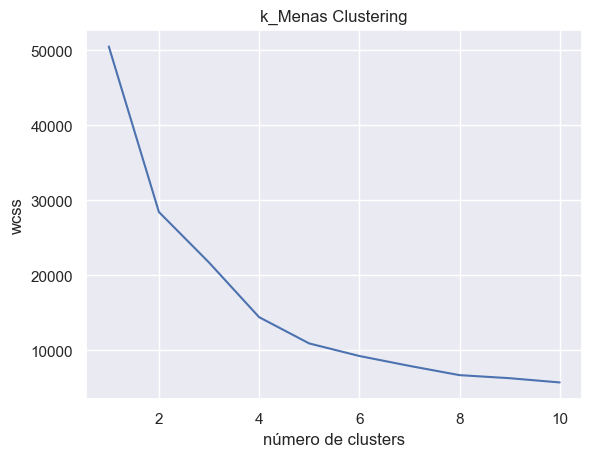

In [374]:
#graficacion del "codo de Jambu"
sb.set()
mp.plot(range(1,11),wcss)
mp.title("k_Menas Clustering")
mp.xlabel("número de clusters")
mp.ylabel("wcss")#weighted clusters sum of squares

In [535]:
#De la gráfica de codo se observa que 4 clusterings es un buen número de clusterings

In [434]:
#criterio de silueta (Silhouette)
from sklearn import datasets
from sklearn.metrics import silhouette_score

In [470]:
X=fields2
for j in range(2,12):
    kmeans=KMeans(n_clusters=j,random_state=42)
    kmeans.fit_predict(X)
    #calculamos el score de silueta
    score=silhouette_score(X,kmeans.labels_,metric="euclidean")
    print("score silhouette: ","k=",j,":",score)

score silhouette:  k= 2 : 0.4822309019106825
score silhouette:  k= 3 : 0.43985884738406383
score silhouette:  k= 4 : 0.4330496070766645
score silhouette:  k= 5 : 0.4431929444274162
score silhouette:  k= 6 : 0.3730871785085532
score silhouette:  k= 7 : 0.38497832644450347
score silhouette:  k= 8 : 0.3962210557542978
score silhouette:  k= 9 : 0.41426309688739205
score silhouette:  k= 10 : 0.41534957309885256
score silhouette:  k= 11 : 0.40567824244587264


In [ ]:
#Del criterio de Silhouette se determina que el número óptimo de clusterings es 2, seguido de 4. Para este
#análisis se optó por 4 clusterins en concordancia con el método de codo.


In [504]:
#Asignación de grupos con AgglomerativeClustering
from sklearn.cluster import AgglomerativeClustering
cluster=AgglomerativeClustering(n_clusters=4,metric="euclidean",linkage="ward")
grupos=cluster.fit_predict(fields2)
grupos


array([2, 2, 1, ..., 0, 0, 0], dtype=int64)

In [509]:
#elementos en cada grupo
total_grupos=pd.Series(grupos)
total_grupos.value_counts()

0    8623
2    5975
1    5350
3      52
Name: count, dtype: int64

In [512]:
#asignación de grupo a cada producto
dataframe=pd.DataFrame(grupos,columns=["grupos"])
dataframe

,grupos
0,2
1,2
2,1
3,2
4,2
...,...
19995,0
19996,0
19997,0
19998,0


In [514]:
#union de grupos a la tabla de datos de cada artículo
dataframe2=pd.concat([union3,dataframe],axis=1,join="inner")
dataframe2.head(10)

,NUMERO DE SEMANAS,FECHA,FABRICANTE,MARCA,CODIGO,DESCRIPCIÓN DEL PRODUCTO,CATEGORIA,FORMATO,ATTR1,ATTR2,ATTR3,TOTAL DE UNIDADES VENDIDAS,VALOR TOTAL DE VENTAS,TOTAL DE UNIDADES PROMEDIO SEMANAL,REGION,SEGMENTO,grupos
0,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.008,0.036,2.667,TOTAL AUTOS AREA 1,BLEACH,2
1,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.021,0.095,21.000,TOTAL AUTOS AREA 2,BLEACH,2
2,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.435,1.957,11.154,TOTAL AUTOS SCANNING MEXICO,BLEACH,1
3,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.008,0.036,8.000,TOTAL AUTOS AREA 3,BLEACH,2
4,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.098,0.441,14.000,TOTAL AUTOS AREA 4,BLEACH,2
5,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.010,0.045,5.000,TOTAL AUTOS AREA 5,BLEACH,1
6,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,0.290,1.305,11.600,TOTAL AUTOS AREA 6,BLEACH,1
7,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,8.176,69.425,34.792,TOTAL AUTOS AREA 1,BLEACH,2
8,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,3.220,28.083,52.787,TOTAL AUTOS AREA 2,BLEACH,2
9,1,2022-01-09,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,12.399,106.325,35.225,TOTAL AUTOS SCANNING MEXICO,BLEACH,1


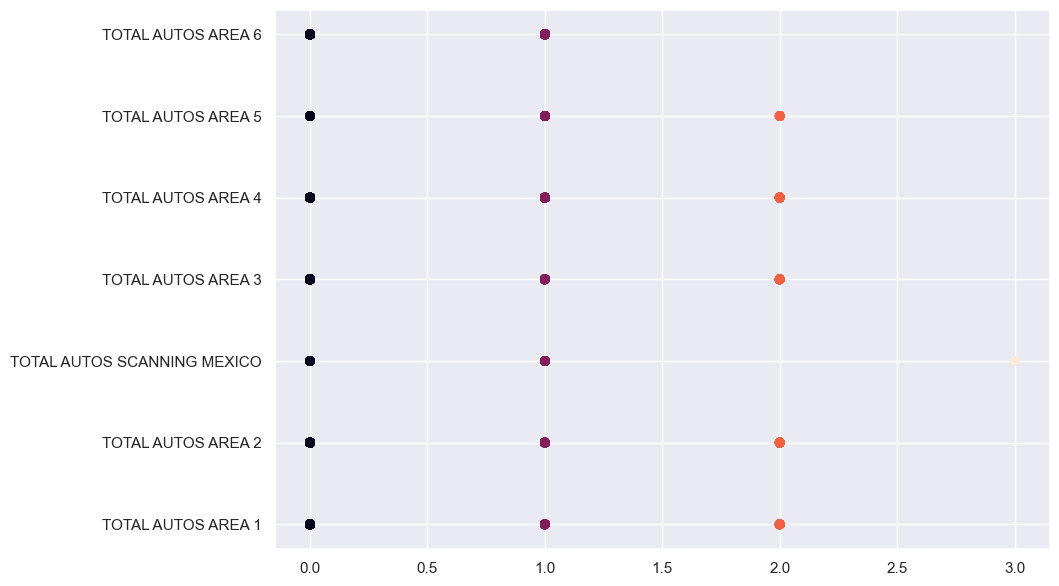

In [516]:
#Grafica de grupos por region 
from sklearn.cluster import KMeans
mp.figure(figsize=(10,7))
mp.scatter(dataframe2.iloc[:,16],dataframe2.iloc[:,14],c=cluster.labels_)
mp.savefig("scatter.png")

#de esta tabla se puede observar que el grupo 0 y 1 se vende en todas las regiones, que el grupo 2 se vende 
#en todas menos en "area 6" y en "SCANNING MEXICO" y que el grupo 3 se vende solo en "SCANNING MEXICO".

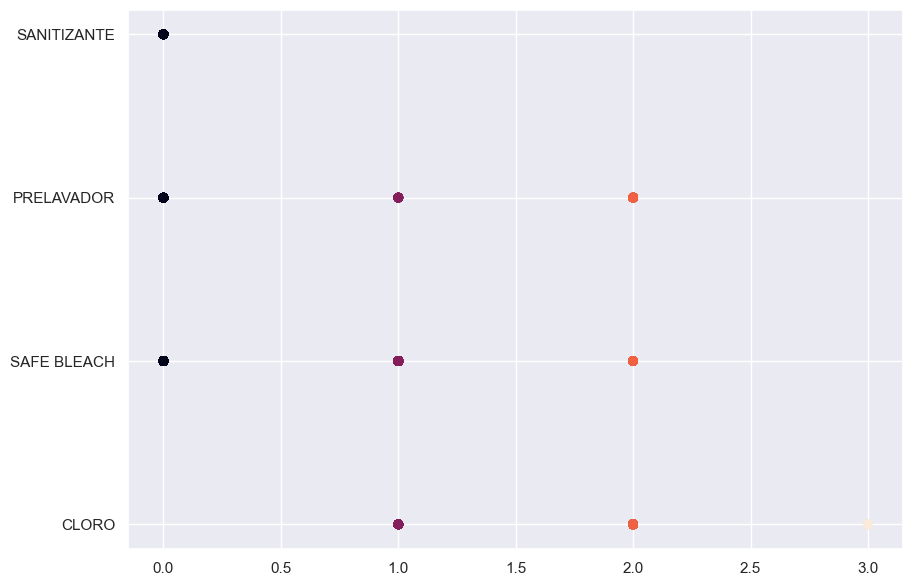

In [533]:
#Grafica de grupos por ATTR1 
from sklearn.cluster import KMeans
mp.figure(figsize=(10,7))
mp.scatter(dataframe2.iloc[:,16],dataframe2.iloc[:,8],c=cluster.labels_)
mp.savefig("scatter.png")

#De aquí se observa que al grupo 3 solo se le atribuye el cloro y por el contrario el grupo 0 no contiene al cloro.
#Además el grupo 1 y 2 son iguales en estos atributos.

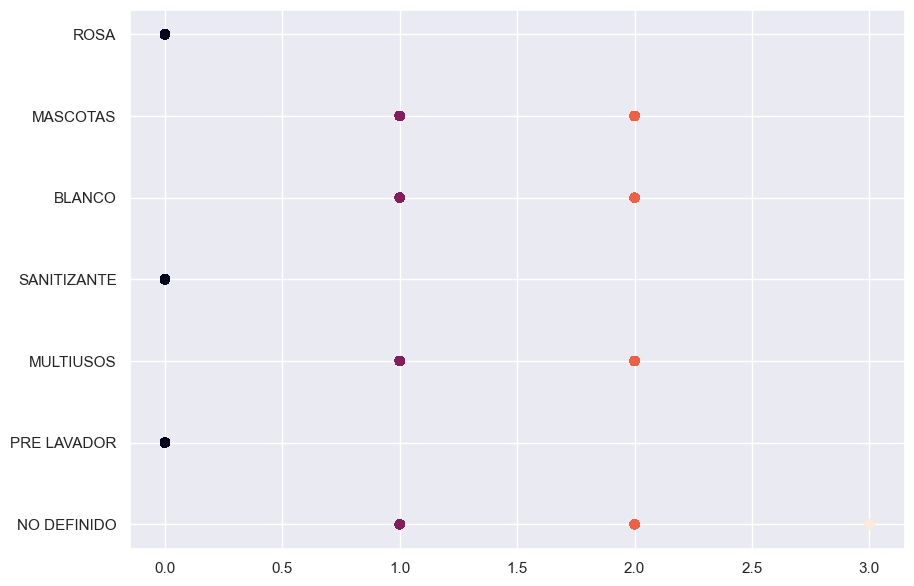

In [518]:
#Grafica de atributos por ATT3
from sklearn.cluster import KMeans
mp.figure(figsize=(10,7))
mp.scatter(dataframe2.iloc[:,16],dataframe2.iloc[:,10],c=cluster.labels_)
mp.savefig("scatter.png")

#Se observa que el grupo 3 no tiene definida su utilidad. El grupo 1 y 5 también permanecen iguales en este 
#atributo.

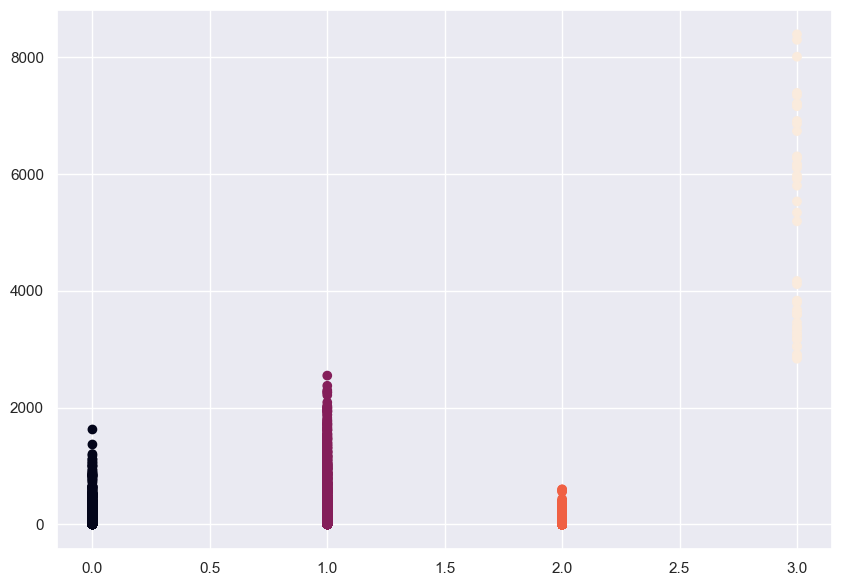

In [565]:
#Grafica de atributos por valor total de ventas 
from sklearn.cluster import KMeans
mp.figure(figsize=(10,7))
mp.scatter(dataframe2.iloc[:,16],dataframe2.iloc[:,12],c=cluster.labels_)
mp.savefig("scatter.png")


#de aquí se observa una clara división entre el grupo 3 y los demás grupos. Pues el grupo 3 tiene costos más 
#elevados.
#Otro resultado evidente es que los productos del grupo 3 son los que generan más ganancias, incluso aunque solo
#se vendan en una área.
#también se observa que el grupo 3 tiene ganancias más bajas que el resto
#Las características evidentes del grupo 3 son: se ubican en el área "SCANNING MEXICO", son productos a base de 
#cloro, sin uso definido y con altas ganancias.


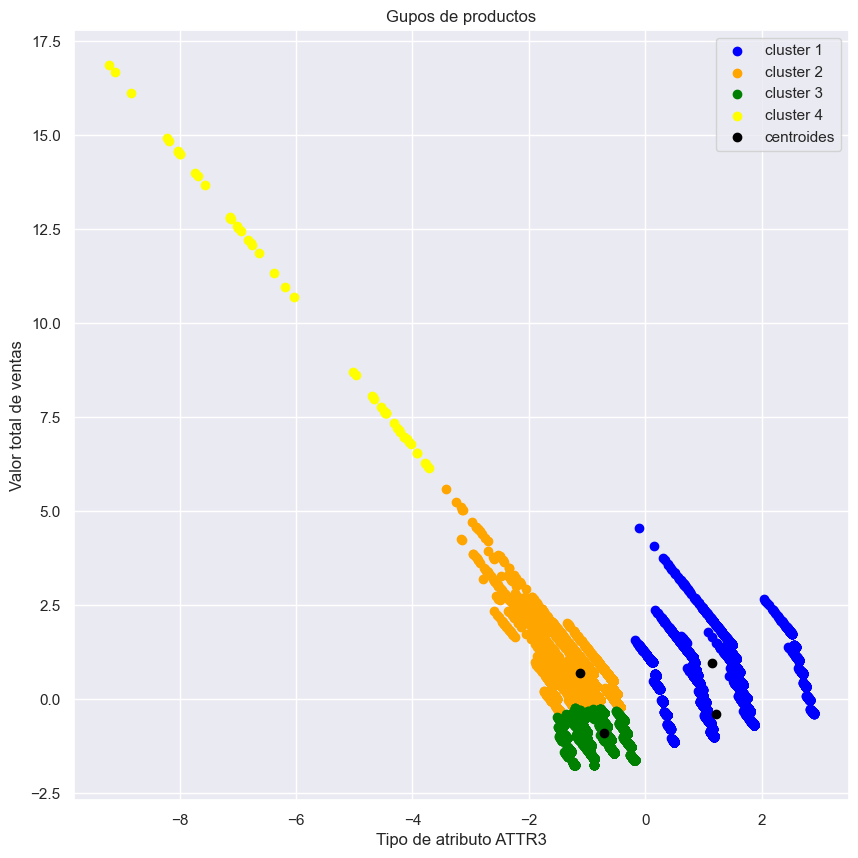

In [531]:
mp.figure(figsize=(10,10))
mp.scatter(fields2[grupos==0,0],fields2[grupos==0,1],c="blue",label="cluster 1")
mp.scatter(fields2[grupos==1,0],fields2[grupos==1,1],c="orange",label="cluster 2")
mp.scatter(fields2[grupos==2,0],fields2[grupos==2,1],c="green",label="cluster 3")
mp.scatter(fields2[grupos==3,0],fields2[grupos==3,1],c="yellow",label="cluster 4")
mp.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c="black",label="centroides")
mp.title("Gupos de productos")
mp.xlabel("Tipo de atributo ATTR3")
mp.ylabel("Valor total de ventas")
mp.savefig("grupos de flores")
mp.legend()
#mp.legend()

#De la gráfica de clusters se puede apreciar la separación del grupo 3 (cluster 4) de los otros 3 grupos.

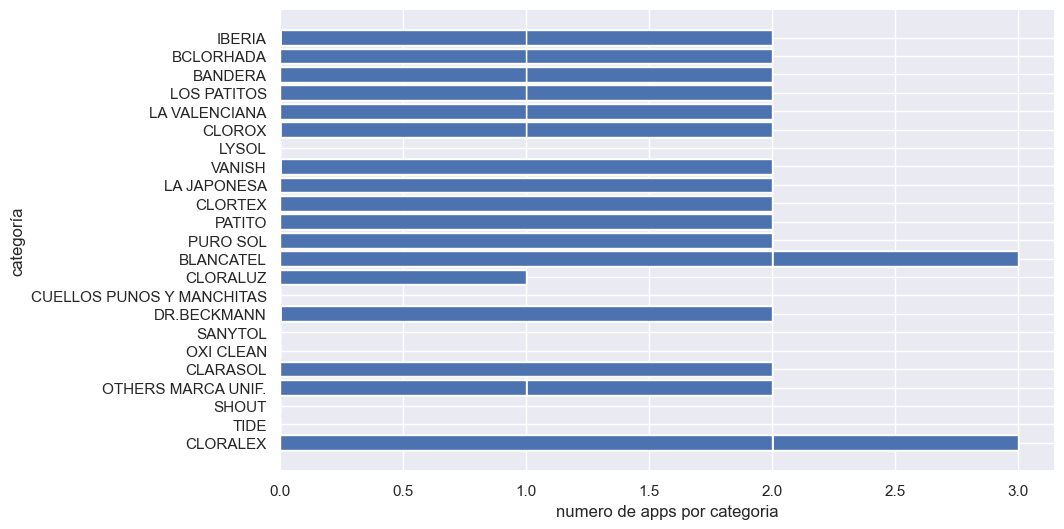

In [549]:
#histograma de marca por grupo
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 6))
plt.barh(dataframe2.iloc[:,3],dataframe2.iloc[:,16],align="center")
plt.xlabel("numero de apps por categoria")
plt.ylabel("categoría")
plt.show()

#De esta gráfica se puede ver que las marcas presentes en el grupo 3 son blancatel y cloralex, por lo que son las #que generan más ganancia. Mientras que las marcas que solo están en el grupo 2 son: Vanish, la japonesa, clortex, #patito, puro sol, Dr.beckmann y clarason. Que son las que generan menos ganacia.

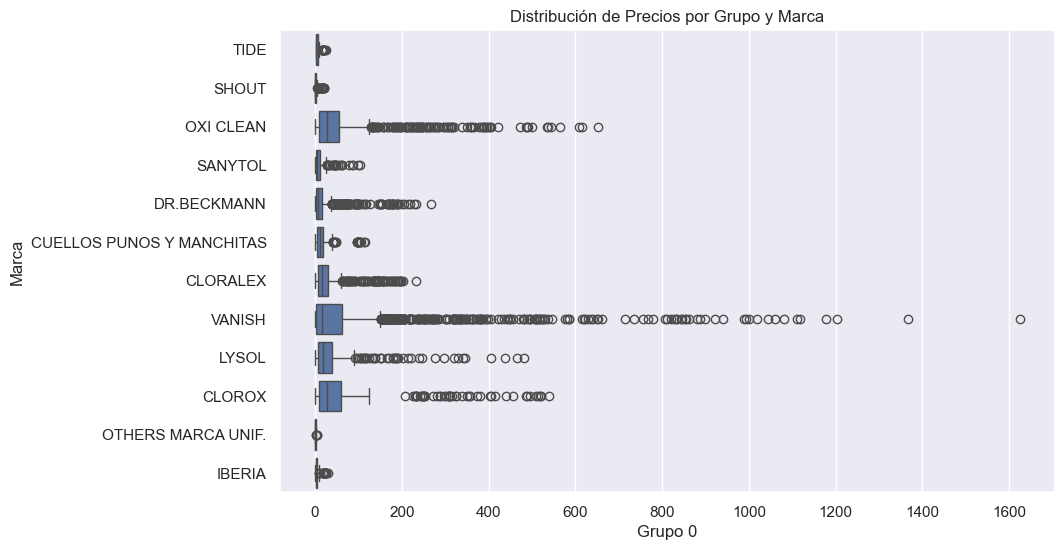

In [587]:
#seleccionar datos del grupo 0 y graficarlos por ventas y marca 
grupo0=dataframe2[dataframe2["grupos"]==0]
plt.figure(figsize=(10, 6))
sns.boxplot(x="VALOR TOTAL DE VENTAS", y="MARCA", data=grupo0)
plt.title('Distribución de Precios por Grupo y Marca')
plt.xlabel('Grupo 0')
plt.ylabel('Marca')
plt.show()

#Del grupo cero los productos que más se venden son de la marca Vanish, clorox y oxi clean.
#Y los que menos se venden son de la marca tide, shout e iberia. De vanish hay algunos productos que generan más 
#ganancia de lo habitual

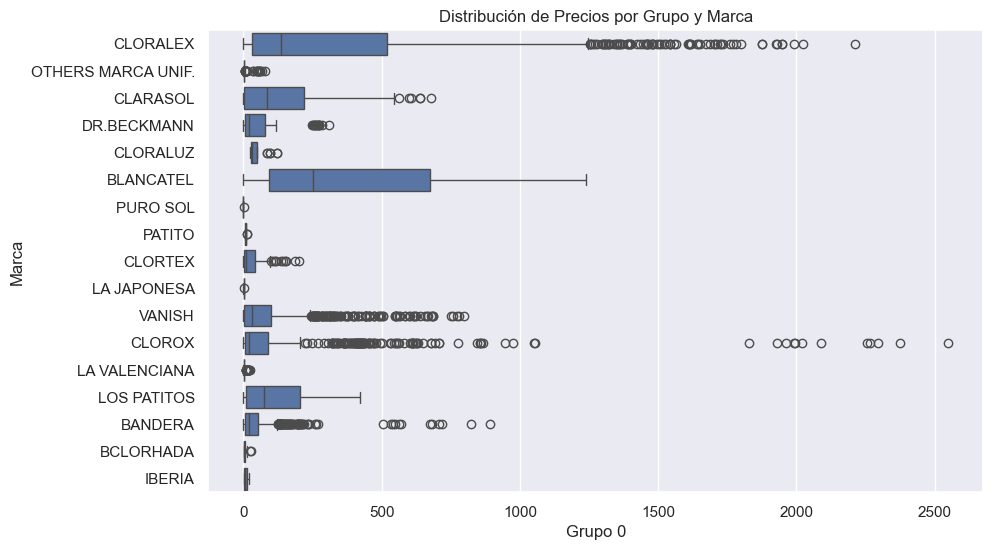

In [589]:
#seleccionar datos del grupo 1 y graficarlos por ventas y marca 
grupo0=dataframe2[dataframe2["grupos"]==1]
plt.figure(figsize=(10, 6))
sns.boxplot(x="VALOR TOTAL DE VENTAS", y="MARCA", data=grupo0)
plt.title('Distribución de Precios por Grupo y Marca')
plt.xlabel('Grupo 1')
plt.ylabel('Marca')
plt.show()

#Del grupo uno las marcas más vendidas son blancatel y cloralex. Teniendo cloralex productos con ganancias
#mayores de lo habitual

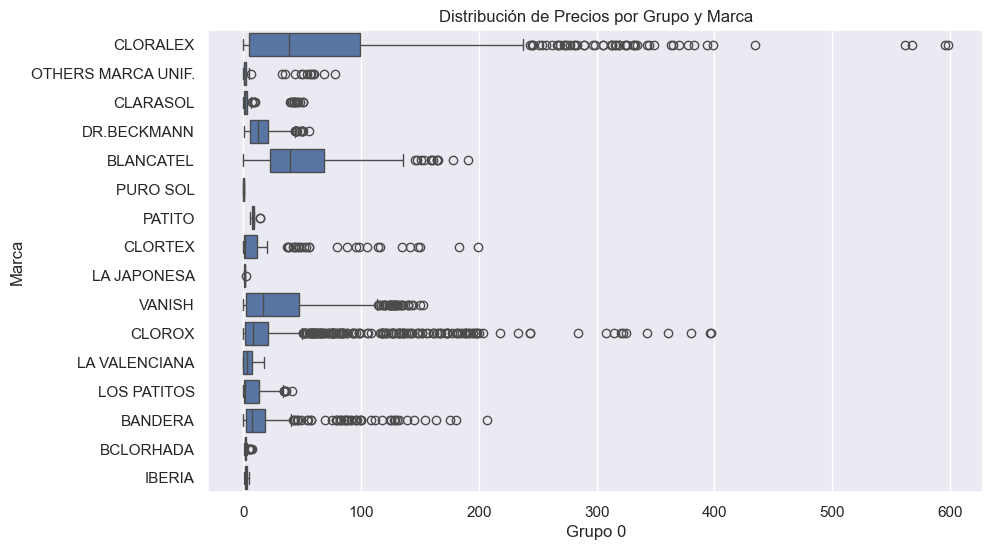

In [593]:
#seleccionar datos del grupo 2 y graficarlos por ventas y marca 
grupo0=dataframe2[dataframe2["grupos"]==2]
plt.figure(figsize=(10, 6))
sns.boxplot(x="VALOR TOTAL DE VENTAS", y="MARCA", data=grupo0)
plt.title('Distribución de Precios por Grupo y Marca')
plt.xlabel('Grupo 2')
plt.ylabel('Marca')
plt.show()

#El grupo 2 efecticamente es en donde menos se vende siendo las marcas con menor ganancia: Puro sol, La japonesa, 
#BClorhada e Ibera. Y la que más se vende cloralex.

#Una razón de que el grupo 2 no tenga tantas ventas es que no se venden en el área donde hay más ganancias que es
#en "SCANNING MEXICO".

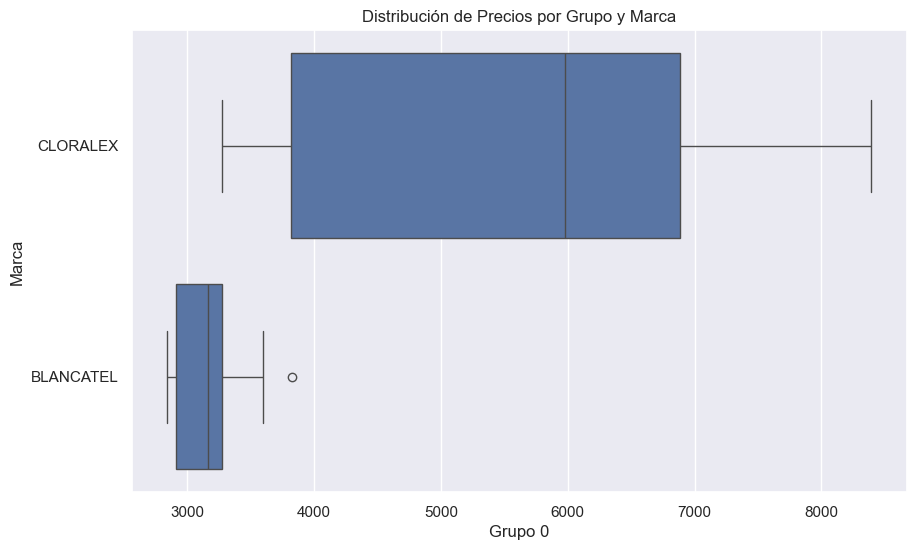

In [595]:
#seleccionar datos del grupo 3 y graficarlos por ventas y marca 
grupo0=dataframe2[dataframe2["grupos"]==3]
plt.figure(figsize=(10, 6))
sns.boxplot(x="VALOR TOTAL DE VENTAS", y="MARCA", data=grupo0)
plt.title('Distribución de Precios por Grupo y Marca')
plt.xlabel('Grupo 3')
plt.ylabel('Marca')
plt.show()

#Como ya se había visto el cloro abarca la mayor cantidad de ganancias y en particular la marca cloralex

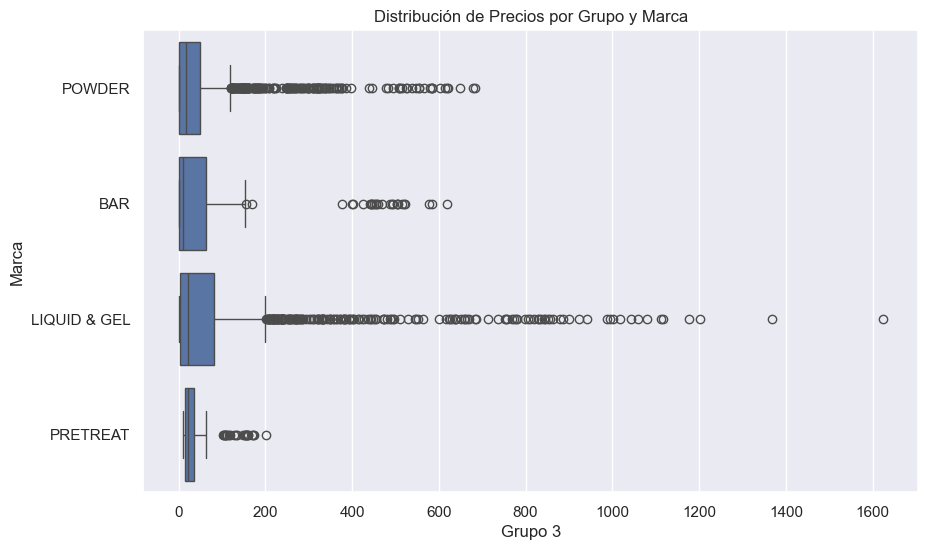

In [610]:
#seleccionar datos del grupo 3 y graficarlos por ventas y marca 
grupo0=dataframe2[dataframe2["MARCA"]=="VANISH"]
plt.figure(figsize=(10, 6))
sns.boxplot(x="VALOR TOTAL DE VENTAS", y="SEGMENTO", data=grupo0)
plt.title('Distribución de Precios por Grupo y Marca')
plt.xlabel('Grupo 3')
plt.ylabel('Marca')
plt.show()

#De esta última gráfica se observa que para la marca vanish los segmentos con menos ventas son los de "PRETREAT" #y "BAR" que generan muy pocas ganancias, pues parece que la gente prefiere presentaciones en "LIQUID & GEL" y en
#"POWDER".
#Así para que vanish genere más ganancias tendría que ofrecer sus productos en el área de "SCANNING MEXICO" y 
#ofrecer productos con presentaciones en "LIQUID","GEL" o "POWDER". Además de dar más promoción a sus artículos con CLORO.